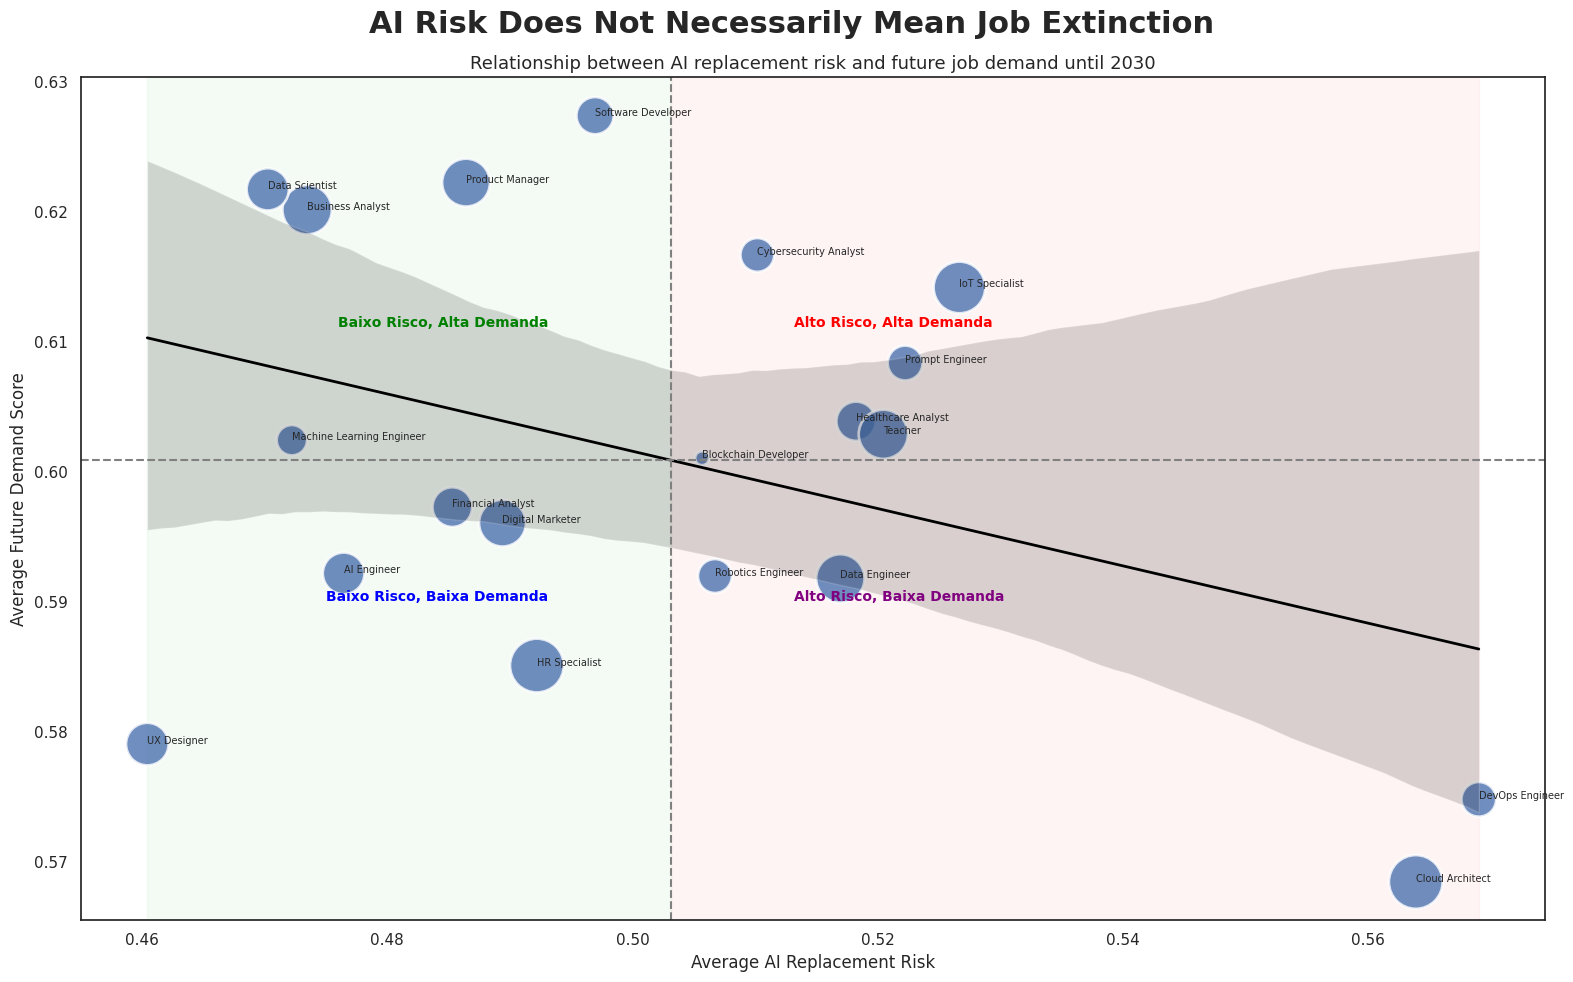

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------
# CONFIGURAÇÃO VISUAL
# -----------------------

sns.set_theme(style="white")

plt.rcParams["figure.figsize"] = (16,10)
plt.rcParams["font.size"] = 12

# -----------------------
# CARREGAR DADOS
# -----------------------

df = pd.read_csv("AI_Impact_on_Jobs_2030.csv")

# médias por profissão

jobs = (
    df.groupby("Job_Title")
    .agg({
        "AI_Replacement_Risk":"mean",
        "Future_Demand_Score":"mean",
        "Average_Salary_USD":"mean"
    })
    .reset_index()
)

# -----------------------
# MÉDIAS GERAIS
# -----------------------

x_mean = jobs["AI_Replacement_Risk"].mean()
y_mean = jobs["Future_Demand_Score"].mean()

# -----------------------
# FIGURA
# -----------------------

fig, ax = plt.subplots()

# Quadrantes

ax.axvspan(
    jobs["AI_Replacement_Risk"].min(),
    x_mean,
    color="#D8F3DC",
    alpha=0.3
)

ax.axvspan(
    x_mean,
    jobs["AI_Replacement_Risk"].max(),
    color="#FFD6D6",
    alpha=0.25
)

# Adicionar rótulos aos quadrantes
ax.text(x_mean - 0.01, y_mean + 0.01, 'Baixo Risco, Alta Demanda', fontsize=10, ha='right', va='bottom', color='green', weight='bold')
ax.text(x_mean + 0.01, y_mean + 0.01, 'Alto Risco, Alta Demanda', fontsize=10, ha='left', va='bottom', color='red', weight='bold')
ax.text(x_mean - 0.01, y_mean - 0.01, 'Baixo Risco, Baixa Demanda', fontsize=10, ha='right', va='top', color='blue', weight='bold')
ax.text(x_mean + 0.01, y_mean - 0.01, 'Alto Risco, Baixa Demanda', fontsize=10, ha='left', va='top', color='purple', weight='bold')


# Scatter

scatter = sns.scatterplot(
    data=jobs,
    x="AI_Replacement_Risk",
    y="Future_Demand_Score",
    size="Average_Salary_USD", # Revert to original behavior: size mapped to Average_Salary_USD
    sizes=(100,1500), # Revert to original behavior
    alpha=0.8,
    legend=False # Keep legend suppressed as requested
)

# Linha de tendência

sns.regplot(
    data=jobs,
    x="AI_Replacement_Risk",
    y="Future_Demand_Score",
    scatter=False,
    color="black",
    line_kws={"linewidth":2}
)

# Linhas médias

plt.axvline(
    x_mean,
    color="gray",
    linestyle="--"
)

plt.axhline(
    y_mean,
    color="gray",
    linestyle="--"
)

# Destacar profissões mais interessantes

# Alterado para mostrar todas as profissões, não apenas as 10 principais
for _, row in jobs.iterrows():

    plt.annotate(
        row["Job_Title"],
        (
            row["AI_Replacement_Risk"],
            row["Future_Demand_Score"]
        ),
        fontsize=7 # Reduzindo o tamanho da fonte para melhor legibilidade com mais anotações
    )

# Títulos

plt.suptitle(
    "AI Risk Does Not Necessarily Mean Job Extinction",
    fontsize=22,
    fontweight="bold"
)

plt.title(
    "Relationship between AI replacement risk and future job demand until 2030",
    fontsize=13
)

plt.xlabel(
    "Average AI Replacement Risk"
)

plt.ylabel(
    "Average Future Demand Score"
)

plt.tight_layout()

plt.savefig(
    "visualizacao_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()